# Simple Neural Network in Python using TensorFlow

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Steps before creating a Neural Network

In [4]:
#remove warnings
import warnings
warnings.filterwarnings('ignore')

#Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Preprocessing
# Dropping rows with missing 'age' and 'embarked' values
titanic.dropna(subset=['age', 'embarked'], inplace = True)

# Converting categorial variables to dummy variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck', ], drop_first= True)

# Selecting features and target
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis = 1)
y = titanic['survived']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Standarized the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Building the model

#define the layers of model
input_layer = tf.keras.layers.Dense(10, activation='relu', input_shape= (X_train.shape[1],))  #input layer
output_layer = tf.keras.layers.Dense(1, activation= 'sigmoid')  #output layer

#combine the layers into a model
model = tf.keras.models.Sequential([input_layer,
                                 output_layer])

# Compile the model
model.compile(optimizer= 'adam',
              loss= 'binary_crossentropy',
              metrics= ['accuracy'])

In [6]:
# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6503 - loss: 0.6234  
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 0.5886 
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7170 - loss: 0.5607 
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7487 - loss: 0.5372 
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.5172 
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4994 
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8120 - loss: 0.4833 
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8102 - loss: 0.4696 
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8120 - loss: 0.4566 
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8137 - loss: 0.4456 
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8137 - loss: 0.4356 
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [7]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7762 - loss: 0.5593  
Test Accuracy: 0.7762237787246704
Test Loss: 0.5592761039733887


# **Assigment:** Plot the Loss and Accuracy of model

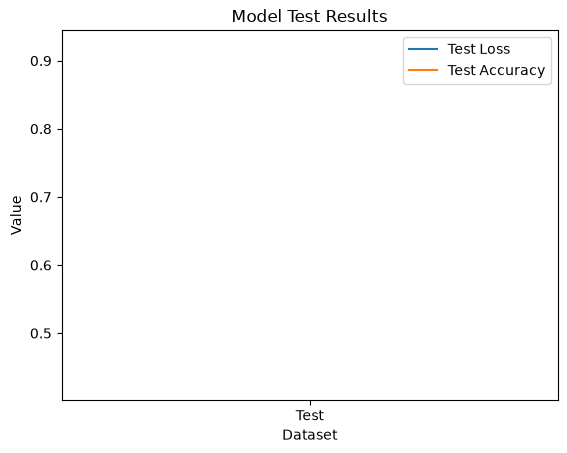

In [10]:
import matplotlib.pyplot as plt

plt.plot(['Test'], [loss])

plt.plot(['Test'], [accuracy])

plt.title('Model Test Results')

plt.ylabel('Value')

plt.xlabel('Dataset')

plt.legend(['Test Loss', 'Test Accuracy'], loc='upper right')

plt.show()

# Complete code

In [9]:
%%time
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

#remove warnings
import warnings
warnings.filterwarnings('ignore')

#Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Preprocessing
# Dropping rows with missing 'age' and 'embarked' values
titanic.dropna(subset=['age', 'embarked'], inplace = True)

# Converting categorial variables to dummy variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck', ], drop_first= True)

# Selecting features and target
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis = 1)
y = titanic['survived']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Standarized the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ......Building the model......
#define the layers of model
input_layer = tf.keras.layers.Dense(10, activation='relu', input_shape= (X_train.shape[1],))  #input layer
output_layer = tf.keras.layers.Dense(1, activation= 'sigmoid')  #output layer

#combine the layers into a model
model = tf.keras.models.Sequential([input_layer,
                                 output_layer])

# Compile the model
model.compile(optimizer= 'adam',
              loss= 'binary_crossentropy',
              metrics= ['accuracy'])

# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4266 - loss: 0.9199  
Test Accuracy: 0.42657342553138733
Test Loss: 0.9198893308639526
CPU times: total: 281 ms
Wall time: 252 ms
